SVM Modeling
--------------

An SVM-based fraud detection pipeline that identifies fraudulent Medicare providers from a heavily imbalanced dataset using undersampling, feature scaling, and hyperparameter tuning.

Initially attempted a complex FDUS (Logistic Regression and SVM varients) boundary aware undersampling approach with Stratified Group K-Fold CV and SVM, but poor performance led to a switch in approach. A simpler RandomUnderSampler with a single train/test split, hyperparameter tuning and SVM achievied a final PR-AUC of 0.8724 and recall of 0.5455

In [1]:
# Track model training time
from time import time

# Handle arrays and tables. Also visuals.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Split, Model, Tune and Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Evaluate model performance
from sklearn.metrics import (precision_score, recall_score, f1_score, average_precision_score, roc_auc_score)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Suppress all ConvergenceWarnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# Load the Dataset
df = pd.read_csv("/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv")

print(f"Shape of the file: {df.shape}")


# Display first few rows
print("\nFirst few rows:")
print(df.head())

Shape of the file: (140827, 69)

First few rows:
          npi rfrg_prvdr_state_abrvtn  target  avg_suplr_mdcr_pymt_amt_sum  \
0  1003000597                      OK       0                     1.692306   
1  1003000597                      OK       0                    23.833223   
2  1003000902                      KY       0                   155.711788   
3  1003000902                      KY       0                    67.361088   
4  1003000902                      KY       0                    40.802223   

   avg_suplr_mdcr_pymt_amt_min  avg_suplr_mdcr_pymt_amt_max  \
0                     1.692306                     1.692306   
1                     0.112054                     8.331875   
2                     0.087436                    82.163333   
3                     0.028794                    38.227500   
4                     0.098643                    24.145333   

   tot_suplr_nonrntl_hcpcs_cds  tot_suplrs_median  tot_suplrs_min  \
0                          1.0    

In [3]:
# Listing the column names....
print ("The columns in the dataset are as follows:\n")
df.columns.to_list()

The columns in the dataset are as follows:



['npi',
 'rfrg_prvdr_state_abrvtn',
 'target',
 'avg_suplr_mdcr_pymt_amt_sum',
 'avg_suplr_mdcr_pymt_amt_min',
 'avg_suplr_mdcr_pymt_amt_max',
 'tot_suplr_nonrntl_hcpcs_cds',
 'tot_suplrs_median',
 'tot_suplrs_min',
 'tot_suplr_clms_min',
 'tot_suplr_srvcs_min',
 'tot_suplrs_max',
 'tot_suplr_benes_max',
 'tot_suplr_clms_max',
 'accessories_for_oxygen_delivery_devices',
 'breathing_aids',
 'hospital_beds_and_associated_supplies',
 'humidifiers_and_nebulizers_with_related_equipment',
 'infusion_pumps_and_supplies',
 'other_supplies_including_diabetes_supplies_and_contraceptives',
 'oxygen_delivery_systems_and_related_supplies',
 'wheelchairs_components_and_accessories',
 'bene_race_api_cnt',
 'bene_dual_cnt',
 'bene_cc_bh_tobacco_v1_pct',
 'bene_cc_bh_alz_non_alzdem_v2_pct',
 'bene_cc_bh_anxiety_v1_pct',
 'bene_cc_bh_schizo_oth_psy_v1_pct',
 'bene_cc_ph_asthma_v2_pct',
 'bene_cc_ph_ckd_v2_pct',
 'bene_cc_ph_copd_v2_pct',
 'bene_cc_ph_diabetes_v2_pct',
 'bene_cc_ph_hf_non_ihd_v2_pct',
 '

In [4]:
# Looking at count of npis grouping by "target"...
df.groupby(df['target']).count()

,npi,rfrg_prvdr_state_abrvtn,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplrs_median,tot_suplrs_min,tot_suplr_clms_min,tot_suplr_srvcs_min,...,tot_suplr_benes_sum_zscore_by_type,tot_suplr_srvcs_max_zscore,total_payment_zscore_by_type,bene_avg_age_zscore_by_type,bene_avg_risk_scre_zscore_by_type,submitted_to_standardized_ratio_zscore,submitted_to_standardized_ratio_zscore_by_type,claims_per_bene_zscore_by_type,services_per_bene_zscore_by_type,benes_per_supplier_zscore_by_type
target,,,,,,,,,,,,,,,,,,,,,
0,140771,140771,140771,140771,140771,140771,140771,140771,140771,140771,...,140771,140771,140771,140771,140771,140771,140771,140771,140771,140771
1,56,56,56,56,56,56,56,56,56,56,...,56,56,56,56,56,56,56,56,56,56


In [5]:
# Checking for Nulls i neach column..

print(df.isnull().sum()[df.isnull().sum() > 0])

# No nulls?


Series([], dtype: int64)


In [6]:
# String/categorical columns
print(df.dtypes[df.dtypes == 'object'])

# Boolean columns (if any)
print(df.dtypes[df.dtypes == 'bool'])         # Boolean columns

rfrg_prvdr_state_abrvtn    object
specialty_type             object
specialty                  object
dtype: object
Series([], dtype: object)


Training Configuration
--------

In [7]:
# Define key column names
target_col = 'target'
npi_col = 'npi'

# Random state for reproducibility
random_state = 42

primary_metric = 'average_precision'

# FDUS configuration
fdus_ratio = 5.0
fdus_alpha = 0.5
fdus_n_clusters = 30

# Cross-validation folds
n_cv_folds = 5

# Columns to exclude from features
exclude_cols = [
    'npi', 'rfrg_prvdr_state_abrvtn', 'year', 'target',
    'og_specialty_name', 'first_payment_date', 'last_payment_date',
    'specialty_type', 'specialty'
]

def evaluate_predictions(y_true, y_pred, y_pred_proba):
    metrics = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_pred_proba),
        'roc_auc': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics

# Create a helper to find the best classification threshold
def find_best_threshold(y_true, y_pred_proba):
    # Generate the precision-recall curve points
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_pred_proba)

    # Return a default threshold if no thresholds are available
    if len(thresholds) == 0:
        return 0.50, pd.DataFrame({'threshold': [0.50], 'precision': [precision_vals[-1]],
                                    'recall': [recall_vals[-1]], 'f1_score': [0.0]})

    # Align precision and recall with the threshold array
    aligned_precision = precision_vals[:-1]
    aligned_recall = recall_vals[:-1]

    # Calculate the F1 score at each threshold
    f1_scores = (2 * aligned_precision * aligned_recall) / np.clip(
        aligned_precision + aligned_recall, 1e-12, None)

    # Build a threshold summary table
    threshold_results = pd.DataFrame({
        'threshold': thresholds,
        'precision': aligned_precision,
        'recall': aligned_recall,
        'f1_score': f1_scores
    }).sort_values('f1_score', ascending=False).reset_index(drop=True)

    # Select the threshold with the best validation F1 score
    best_threshold = float(threshold_results.loc[0, 'threshold'])

    return best_threshold, threshold_results

# FDUS Implementation (Logistic Regression / SVM)
Define the FDUS undersampler based on Zhou et al. (2024). The algorithm:
1. Fits a separating hyperplane using either Logistic Regression or Linear SVM
2. Clusters the majority class with K-Means
3. Applies spatial compression to focus on boundary regions
4. Uses weighted sampling where points closer to the decision boundary have higher selection probability

In [8]:
# FDUS with Logistic Regression 

class FDUSUndersampler:
    """
    FDUS: Fitting Data Distribution with UnderSampling

    Based on Zhou et al. (2024). kNN noise filtering removed - ineffective
    at extreme imbalance ratios (2600:1) where it removes 0 samples.
    """

    def __init__(self, n_clusters=30, alpha=0.5, target_ratio=5.0, random_state=42):
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.target_ratio = target_ratio
        self.random_state = random_state
        self.hyperplane_ = None
        self.cluster_model_ = None
        self.cluster_labels_ = None

    def _get_optimal_hyperplane(self, X, y):
        """Find separating hyperplane using logistic regression"""
        clf = LogisticRegression(max_iter=500, random_state=self.random_state,
                                  solver='saga', n_jobs=-1)
        clf.fit(X, y)
        return clf

    def _compute_distance_to_hyperplane(self, X, clf):
        """Compute perpendicular distance from each point to hyperplane"""
        w = clf.coef_.flatten()
        b = clf.intercept_[0] if hasattr(clf.intercept_, '__len__') else clf.intercept_
        distances = np.abs(np.dot(X, w) + b) / np.linalg.norm(w)
        return distances

    def _weighted_cluster_undersample(self, X_majority, distances, n_samples_target):
        """Weighted Undersampling based on Clustering (WUC) - Algorithm 1 from paper"""
        np.random.seed(self.random_state)

        self.cluster_model_ = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            batch_size=1024,
            n_init=3
        )
        self.cluster_labels_ = self.cluster_model_.fit_predict(X_majority)

        samples_per_cluster = max(1, n_samples_target // self.n_clusters)

        selected_indices = []

        for cluster_id in range(self.n_clusters):
            cluster_mask = self.cluster_labels_ == cluster_id
            cluster_indices = np.where(cluster_mask)[0]

            if len(cluster_indices) == 0:
                continue

            cluster_distances = distances[cluster_indices]

            # L_i,f(x) = L_max - L_min (diameter facing hyperplane)
            L_max = cluster_distances.max()
            L_min = cluster_distances.min()
            L_diameter = L_max - L_min

            # Spatial compression: only sample from boundary region
            COMPRESSION_THRESHOLD = L_min + self.alpha * L_diameter
            boundary_mask = cluster_distances <= COMPRESSION_THRESHOLD
            boundary_indices = cluster_indices[boundary_mask]

            if len(boundary_indices) == 0:
                boundary_indices = cluster_indices

            boundary_distances = distances[boundary_indices]

            # Weighted sampling: closer to boundary = higher weight
            eps = 1e-10
            weights = 1.0 / (boundary_distances + eps)
            weights = weights * np.random.random(len(weights))
            weights = weights / weights.sum()

            n_to_sample = min(samples_per_cluster, len(boundary_indices))

            if n_to_sample > 0:
                sampled = np.random.choice(
                    boundary_indices,
                    size=n_to_sample,
                    replace=False,
                    p=weights
                )
                selected_indices.extend(sampled)

        return np.array(selected_indices)

    def fit_resample(self, X_majority, X_minority, verbose=True):
        """Apply FDUS undersampling"""
        n_minority = len(X_minority)
        n_majority = len(X_majority)

        # Combine for hyperplane fitting
        X_combined = np.vstack([X_majority, X_minority])
        y_combined = np.concatenate([np.zeros(n_majority), np.ones(n_minority)])

        # Step 1: Fit hyperplane
        if verbose:
            print(f"    FDUS: Fitting hyperplane...", end=" ", flush=True)
        self.hyperplane_ = self._get_optimal_hyperplane(X_combined, y_combined)
        if verbose:
            print("done")

        # Step 2: Compute distances
        distances = self._compute_distance_to_hyperplane(X_majority, self.hyperplane_)

        # Step 3: Weighted cluster sampling
        n_target = int(n_minority * self.target_ratio)
        if verbose:
            print(f"    FDUS: Weighted cluster sampling (target: {n_target})...", end=" ", flush=True)
        selected_idx = self._weighted_cluster_undersample(X_majority, distances, n_target)
        if verbose:
            print("done")

        # Build final dataset
        X_resampled = np.vstack([X_minority, X_majority[selected_idx]])
        y_resampled = np.concatenate([np.ones(n_minority), np.zeros(len(selected_idx))])

        # Shuffle
        shuffle_idx = np.random.permutation(len(y_resampled))
        X_resampled = X_resampled[shuffle_idx]
        y_resampled = y_resampled[shuffle_idx]

        if verbose:
            print(f"    FDUS: {len(X_resampled):,} samples "
                  f"({(y_resampled == 0).sum():,} maj / {(y_resampled == 1).sum()} min)")

        return X_resampled, y_resampled

print("FDUS class defined")

FDUS class defined


# Data Preprocessing
Identify feature types, check data quality, and prepare the feature set.

In [9]:
# Identify feature columns (numeric only, excluding metadata)
exclude_cols_set = exclude_cols
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols_set]

print(f"Number of features kept: {len(feature_cols)}")

# Clean the dataset
df_clean = df[feature_cols + [target_col, npi_col]].dropna().reset_index(drop=True)
print(f"\nNo. of Entires after cleanup: {len(df_clean):,}")

# Separate features, target, and groups
X = df_clean[feature_cols].values
y = df_clean[target_col].values
groups = df_clean[npi_col].values

print(f"\nClass Distribution:")
print(f"  Non-Fraud (0): {(y == 0).sum():,}")
print(f"  Fraud (1): {(y == 1).sum()}")

# Display basic statistics
print("\nBasic statistics for features:")
print(df_clean[feature_cols].describe())

Number of features kept: 64

No. of Entires after cleanup: 140,827

Class Distribution:
  Non-Fraud (0): 140,771
  Fraud (1): 56

Basic statistics for features:
       avg_suplr_mdcr_pymt_amt_sum  avg_suplr_mdcr_pymt_amt_min  \
count                140827.000000                140827.000000   
mean                    338.383343                    45.304431   
std                     737.240101                   290.790826   
min                       0.000000                     0.000000   
25%                      50.080000                     0.778775   
50%                     137.543136                     3.711765   
75%                     363.802523                    18.286951   
max                   94737.962397                 11986.920000   

       avg_suplr_mdcr_pymt_amt_max  tot_suplr_nonrntl_hcpcs_cds  \
count                140827.000000                140827.000000   
mean                    195.725501                     3.751099   
std                     436.330704

In [10]:
######################################################################
#                     SVM HYPERPARAMETER GRID
######################################################################

# Three kernel options (barebones)
# Needs to be expanded .... right now its very limiting.
param_grid = [
    {   # Linear: fast, good for high-dimensional data
        'kernel'       : ['linear'],
        'C'            : [0.01, 0.1, 1, 10],
        'class_weight' : ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
    },
    {   # RBF: handles non-linear boundaries, most commonly best performer
        'kernel'       : ['rbf'],
        'C'            : [0.1, 1, 10, 100],
        'gamma'        : ['scale', 'auto', 0.01, 0.001],
        'class_weight' : ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
    },
    {   # Sigmoid: neural-network-like boundary
        'kernel'       : ['sigmoid'],
        'C'            : [0.1, 1, 10],
        'gamma'        : ['scale', 'auto'],
        'class_weight' : ['balanced']
    }
]


## Attempt 1

In [11]:
######################################################################
# STRATIFIED GROUP K-FOLD CV WITH FDUS + SVM GRID SEARCH
######################################################################

# Outer CV groups by NPI — same provider never leaks across train/test
outer_cv = StratifiedGroupKFold(n_splits=n_cv_folds, shuffle=True, random_state=random_state)

# Result storage
fold_metrics     = []
fold_best_params = []
fold_models      = []
all_test_indices = []
all_test_probas  = []
all_test_labels  = []

start_time = time()

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1} of {n_cv_folds}")
    print(f"{'='*60}")

    # Slice train / test for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"  Train : {len(X_train):,} rows  |  fraud={y_train.sum()}  non-fraud={(y_train==0).sum():,}")
    print(f"  Test  : {len(X_test):,} rows   |  fraud={y_test.sum()}  non-fraud={(y_test==0).sum():,}")

    # Skip if no fraud in test — nothing meaningful to evaluate
    if y_test.sum() == 0:
        print("  SKIPPED — no fraud cases in test fold")
        continue

    # ── Step 1: Scale features ───────────────────────────────────────
    # Always fit scaler on training data only to avoid data leakage
    t = time()
    scaler        = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print(f"  [1/4] Scaling          ... done ({time()-t:.1f}s)")

    # ── Step 2: FDUS undersampling ───────────────────────────────────
    # Undersample majority class (non-fraud) using boundary-aware sampling
    t            = time()
    majority_idx = np.where(y_train == 0)[0]
    minority_idx = np.where(y_train == 1)[0]

    fdus = FDUSUndersampler(
        n_clusters   = fdus_n_clusters,
        alpha        = fdus_alpha,
        target_ratio = fdus_ratio,
        random_state = random_state
    )
    X_train_resampled, y_train_resampled = fdus.fit_resample(
        X_train_scaled[majority_idx],
        X_train_scaled[minority_idx]
    )
    print(f"  [2/4] FDUS resampling  ... done ({time()-t:.1f}s)")

    # ── Step 3: Grid search for best SVM hyperparameters ────────────
    # Inner CV runs only on the resampled training data
    t        = time()
    inner_cv = StratifiedKFold(
        n_splits     = min(3, int(y_train_resampled.sum())),
        shuffle      = True,
        random_state = random_state
    )

    grid_search = GridSearchCV(
        estimator  = SVC(probability=True, max_iter=2000, random_state=random_state),
        param_grid = param_grid,
        scoring    = primary_metric,
        cv         = inner_cv,
        n_jobs     = -1,
        verbose    = 0
    )
    grid_search.fit(X_train_resampled, y_train_resampled)
    print(f"  [3/4] Grid search      ... done ({time()-t:.1f}s)")

    best_svm = grid_search.best_estimator_
    fold_best_params.append(grid_search.best_params_)
    fold_models.append((scaler, best_svm))

    print(f"  Best inner CV PR-AUC : {grid_search.best_score_:.4f}")
    print(f"  Best params          : {grid_search.best_params_}")

    # ── Step 4: Evaluate on held-out test fold ───────────────────────
    # Test fold is the original imbalanced data — real-world conditions
    t            = time()
    y_test_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

    all_test_indices.extend(test_idx.tolist())
    all_test_probas.extend(y_test_proba.tolist())
    all_test_labels.extend(y_test.tolist())

    fold_auc_roc = roc_auc_score(y_test, y_test_proba)
    fold_auc_pr  = average_precision_score(y_test, y_test_proba)

    fold_metrics.append({
        'fold'            : fold_idx + 1,
        'auc_roc'         : fold_auc_roc,
        'auc_pr'          : fold_auc_pr,
        'train_fraud'     : int(y_train.sum()),
        'test_fraud'      : int(y_test.sum()),
        'train_resampled' : len(y_train_resampled)
    })

    print(f"  [4/4] Evaluation       ... done ({time()-t:.1f}s)")
    print(f"  Fold AUC-ROC : {fold_auc_roc:.4f}")
    print(f"  Fold AUC-PR  : {fold_auc_pr:.4f}")

######################################################################
# SUMMARY
######################################################################

elapsed       = time() - start_time
cv_results_df = pd.DataFrame(fold_metrics)

print(f"\nCROSS-VALIDATION SUMMARY  ({elapsed:.1f}s total)")
print('-' * 60)
print(cv_results_df.to_string(index=False))
print(f"\nMean AUC-PR  : {cv_results_df['auc_pr'].mean():.4f}  (+/- {cv_results_df['auc_pr'].std():.4f})")
print(f"Mean AUC-ROC : {cv_results_df['auc_roc'].mean():.4f}  (+/- {cv_results_df['auc_roc'].std():.4f})")


FOLD 1 of 5
  Train : 112,633 rows  |  fraud=37  non-fraud=112,596
  Test  : 28,194 rows   |  fraud=19  non-fraud=28,175
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 185)... done
    FDUS: 209 samples (172 maj / 37 min)
  [2/4] FDUS resampling  ... done (48.2s)
  [3/4] Grid search      ... done (1.5s)
  Best inner CV PR-AUC : 0.4695
  Best params          : {'C': 100, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
  [4/4] Evaluation       ... done (0.2s)
  Fold AUC-ROC : 0.5043
  Fold AUC-PR  : 0.0009

FOLD 2 of 5
  Train : 112,672 rows  |  fraud=41  non-fraud=112,631
  Test  : 28,155 rows   |  fraud=15  non-fraud=28,140
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 205)... done
    FDUS: 215 samples (174 maj / 41 min)
  [2/4] FDUS resampling  ... done (48.1s)
  [3/4] Grid search      ... done (0.2s)
  Best inner CV PR-

Overall results are ok. Maybe using linear SVM instead in of Logistic Regression might improve the performance

## Attempt 2

The same df_clean and parameters (for hyperparameter tuning) will be used.

In [12]:
# FDUS with Linear SVM

class FDUSUndersampler:
    """
    FDUS: Fitting Data Distribution with UnderSampling

    Based on Zhou et al. (2024). kNN noise filtering removed - ineffective
    at extreme imbalance ratios (2600:1) where it removes 0 samples.
    """

    def __init__(self, n_clusters=30, alpha=0.5, target_ratio=5.0, random_state=42):
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.target_ratio = target_ratio
        self.random_state = random_state
        self.hyperplane_ = None
        self.cluster_model_ = None
        self.cluster_labels_ = None

    def _get_optimal_hyperplane(self, X, y):
        """Find separating hyperplane using linear SVM"""
        clf = LinearSVC(max_iter=2000, random_state=self.random_state)
        clf.fit(X, y)
        return clf

    def _compute_distance_to_hyperplane(self, X, clf):
        """Compute perpendicular distance from each point to hyperplane"""
        w = clf.coef_.flatten()
        b = clf.intercept_[0] if hasattr(clf.intercept_, '__len__') else clf.intercept_
        distances = np.abs(np.dot(X, w) + b) / np.linalg.norm(w)
        return distances

    def _weighted_cluster_undersample(self, X_majority, distances, n_samples_target):
        """Weighted Undersampling based on Clustering (WUC) - Algorithm 1 from paper"""
        np.random.seed(self.random_state)

        self.cluster_model_ = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            batch_size=1024,
            n_init=3
        )
        self.cluster_labels_ = self.cluster_model_.fit_predict(X_majority)

        samples_per_cluster = max(1, n_samples_target // self.n_clusters)

        selected_indices = []

        for cluster_id in range(self.n_clusters):
            cluster_mask = self.cluster_labels_ == cluster_id
            cluster_indices = np.where(cluster_mask)[0]

            if len(cluster_indices) == 0:
                continue

            cluster_distances = distances[cluster_indices]

            # L_i,f(x) = L_max - L_min (diameter facing hyperplane)
            L_max = cluster_distances.max()
            L_min = cluster_distances.min()
            L_diameter = L_max - L_min

            # Spatial compression: only sample from boundary region
            COMPRESSION_THRESHOLD = L_min + self.alpha * L_diameter
            boundary_mask = cluster_distances <= COMPRESSION_THRESHOLD
            boundary_indices = cluster_indices[boundary_mask]

            if len(boundary_indices) == 0:
                boundary_indices = cluster_indices

            boundary_distances = distances[boundary_indices]

            # Weighted sampling: closer to boundary = higher weight
            eps = 1e-10
            weights = 1.0 / (boundary_distances + eps)
            weights = weights * np.random.random(len(weights))
            weights = weights / weights.sum()

            n_to_sample = min(samples_per_cluster, len(boundary_indices))

            if n_to_sample > 0:
                sampled = np.random.choice(
                    boundary_indices,
                    size=n_to_sample,
                    replace=False,
                    p=weights
                )
                selected_indices.extend(sampled)

        return np.array(selected_indices)

    def fit_resample(self, X_majority, X_minority, verbose=True):
        """Apply FDUS undersampling"""
        n_minority = len(X_minority)
        n_majority = len(X_majority)

        # Combine for hyperplane fitting
        X_combined = np.vstack([X_majority, X_minority])
        y_combined = np.concatenate([np.zeros(n_majority), np.ones(n_minority)])

        # Step 1: Fit hyperplane
        if verbose:
            print(f"    FDUS: Fitting hyperplane...", end=" ", flush=True)
        self.hyperplane_ = self._get_optimal_hyperplane(X_combined, y_combined)
        if verbose:
            print("done")

        # Step 2: Compute distances
        distances = self._compute_distance_to_hyperplane(X_majority, self.hyperplane_)

        # Step 3: Weighted cluster sampling
        n_target = int(n_minority * self.target_ratio)
        if verbose:
            print(f"    FDUS: Weighted cluster sampling (target: {n_target})...", end=" ", flush=True)
        selected_idx = self._weighted_cluster_undersample(X_majority, distances, n_target)
        if verbose:
            print("done")

        # Build final dataset
        X_resampled = np.vstack([X_minority, X_majority[selected_idx]])
        y_resampled = np.concatenate([np.ones(n_minority), np.zeros(len(selected_idx))])

        # Shuffle
        shuffle_idx = np.random.permutation(len(y_resampled))
        X_resampled = X_resampled[shuffle_idx]
        y_resampled = y_resampled[shuffle_idx]

        if verbose:
            print(f"    FDUS: {len(X_resampled):,} samples "
                  f"({(y_resampled == 0).sum():,} maj / {(y_resampled == 1).sum()} min)")

        return X_resampled, y_resampled

print("FDUS class defined")


FDUS class defined


In [13]:
######################################################################
# STRATIFIED GROUP K-FOLD CV WITH FDUS + SVM GRID SEARCH
######################################################################

# Outer CV groups by NPI — same provider never leaks across train/test
outer_cv = StratifiedGroupKFold(n_splits=n_cv_folds, shuffle=True, random_state=random_state)

# Result storage
fold_metrics     = []
fold_best_params = []
fold_models      = []
all_test_indices = []
all_test_probas  = []
all_test_labels  = []

start_time = time()

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1} of {n_cv_folds}")
    print(f"{'='*60}")

    # Slice train / test for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"  Train : {len(X_train):,} rows  |  fraud={y_train.sum()}  non-fraud={(y_train==0).sum():,}")
    print(f"  Test  : {len(X_test):,} rows   |  fraud={y_test.sum()}  non-fraud={(y_test==0).sum():,}")

    # Skip if no fraud in test — nothing meaningful to evaluate
    if y_test.sum() == 0:
        print("  SKIPPED — no fraud cases in test fold")
        continue

    # ── Step 1: Scale features ───────────────────────────────────────
    # Always fit scaler on training data only to avoid data leakage
    t = time()
    scaler        = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print(f"  [1/4] Scaling          ... done ({time()-t:.1f}s)")

    # ── Step 2: FDUS undersampling ───────────────────────────────────
    # Undersample majority class (non-fraud) using boundary-aware sampling
    t            = time()
    majority_idx = np.where(y_train == 0)[0]
    minority_idx = np.where(y_train == 1)[0]

    fdus = FDUSUndersampler(
        n_clusters   = fdus_n_clusters,
        alpha        = fdus_alpha,
        target_ratio = fdus_ratio,
        random_state = random_state
    )
    X_train_resampled, y_train_resampled = fdus.fit_resample(
        X_train_scaled[majority_idx],
        X_train_scaled[minority_idx]
    )
    print(f"  [2/4] FDUS resampling  ... done ({time()-t:.1f}s)")

    # ── Step 3: Grid search for best SVM hyperparameters ────────────
    # Inner CV runs only on the resampled training data
    t        = time()
    inner_cv = StratifiedKFold(
        n_splits     = min(3, int(y_train_resampled.sum())),
        shuffle      = True,
        random_state = random_state
    )

    grid_search = GridSearchCV(
        estimator  = SVC(probability=True, max_iter=2000, random_state=random_state),
        param_grid = param_grid,
        scoring    = primary_metric,
        cv         = inner_cv,
        n_jobs     = -1,
        verbose    = 0
    )
    grid_search.fit(X_train_resampled, y_train_resampled)
    print(f"  [3/4] Grid search      ... done ({time()-t:.1f}s)")

    best_svm = grid_search.best_estimator_
    fold_best_params.append(grid_search.best_params_)
    fold_models.append((scaler, best_svm))

    print(f"  Best inner CV PR-AUC : {grid_search.best_score_:.4f}")
    print(f"  Best params          : {grid_search.best_params_}")

    # ── Step 4: Evaluate on held-out test fold ───────────────────────
    # Test fold is the original imbalanced data — real-world conditions
    t            = time()
    y_test_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

    all_test_indices.extend(test_idx.tolist())
    all_test_probas.extend(y_test_proba.tolist())
    all_test_labels.extend(y_test.tolist())

    fold_auc_roc = roc_auc_score(y_test, y_test_proba)
    fold_auc_pr  = average_precision_score(y_test, y_test_proba)

    fold_metrics.append({
        'fold'            : fold_idx + 1,
        'auc_roc'         : fold_auc_roc,
        'auc_pr'          : fold_auc_pr,
        'train_fraud'     : int(y_train.sum()),
        'test_fraud'      : int(y_test.sum()),
        'train_resampled' : len(y_train_resampled)
    })

    print(f"  [4/4] Evaluation       ... done ({time()-t:.1f}s)")
    print(f"  Fold AUC-ROC : {fold_auc_roc:.4f}")
    print(f"  Fold AUC-PR  : {fold_auc_pr:.4f}")

######################################################################
# SUMMARY
######################################################################

elapsed       = time() - start_time
cv_results_df = pd.DataFrame(fold_metrics)

print(f"\nCROSS-VALIDATION SUMMARY  ({elapsed:.1f}s total)")
print('-' * 60)
print(cv_results_df.to_string(index=False))
print(f"\nMean AUC-PR  : {cv_results_df['auc_pr'].mean():.4f}  (+/- {cv_results_df['auc_pr'].std():.4f})")
print(f"Mean AUC-ROC : {cv_results_df['auc_roc'].mean():.4f}  (+/- {cv_results_df['auc_roc'].std():.4f})")


FOLD 1 of 5
  Train : 112,633 rows  |  fraud=37  non-fraud=112,596
  Test  : 28,194 rows   |  fraud=19  non-fraud=28,175
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 185)... done
    FDUS: 217 samples (180 maj / 37 min)
  [2/4] FDUS resampling  ... done (2.7s)
  [3/4] Grid search      ... done (0.2s)
  Best inner CV PR-AUC : 0.5638
  Best params          : {'C': 10, 'class_weight': {0: 1, 1: 5}, 'gamma': 0.01, 'kernel': 'rbf'}
  [4/4] Evaluation       ... done (0.2s)
  Fold AUC-ROC : 0.6248
  Fold AUC-PR  : 0.0017

FOLD 2 of 5
  Train : 112,672 rows  |  fraud=41  non-fraud=112,631
  Test  : 28,155 rows   |  fraud=15  non-fraud=28,140
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 205)... done
    FDUS: 221 samples (180 maj / 41 min)
  [2/4] FDUS resampling  ... done (3.7s)
  [3/4] Grid search      ... done (0.2s)
  Best inner CV PR-A

The results are better than attempt 1 but still not up to par.....maybe a simpler approach would be appropriate 

## Attempt 3
### Simple SVM Pipeline....
Undersampling, train/test split, scale, train and evaluate but making the process alot more simple.  

In [14]:
# Reworked the hyperparameter tuning so that it fits for the simpler approach, not that big of a change mostly added the svm__ prefix.
param_grid_pipeline = [
    {  
        'svm__kernel'       : ['linear'],
        'svm__C'            : [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500],
        'svm__class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:15}, {0:1, 1:20}, 
                               {0:1, 1:30}, {0:1, 1:50}, {0:1, 1:75}, {0:1, 1:100}]
    },
    {   
        'svm__kernel'       : ['rbf'],
        'svm__C'            : [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000],
        'svm__gamma'        : ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001],
        'svm__class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:15}, {0:1, 1:20}, 
                               {0:1, 1:30}, {0:1, 1:50}, {0:1, 1:75}, {0:1, 1:100}]
    },
    {   
        'svm__kernel'       : ['sigmoid'],
        'svm__C'            : [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500],
        'svm__gamma'        : ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001, 0.00001],
        'svm__coef0'        : [0.0, 0.1, 0.5, 1.0, 2.0, 5.0],
        'svm__class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:20}, 
                               {0:1, 1:50}, {0:1, 1:75}, {0:1, 1:100}]
    },
    {   
        'svm__kernel'       : ['poly'],
        'svm__C'            : [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500],
        'svm__gamma'        : ['scale', 'auto', 0.1, 0.01, 0.001],
        'svm__degree'       : [2, 3, 4, 5],
        'svm__coef0'        : [0.0, 0.1, 0.5, 1.0, 2.0],
        'svm__class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:20}, 
                               {0:1, 1:50}, {0:1, 1:100}]
    }
]

# Performance evaluation function
def evaluate_predictions(y_true, y_pred, y_pred_proba):
    metrics = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_pred_proba),
        'roc_auc': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics



## Note: The same clean_df will be used. 

After resampling: 280 non-fraud / 56 fraud
Fitting 5 folds for each of 12480 candidates, totalling 62400 fits

Best params : {'svm__C': 50, 'svm__class_weight': 'balanced', 'svm__coef0': 2.0, 'svm__degree': 3, 'svm__gamma': 0.001, 'svm__kernel': 'poly'}
Best PR-AUC : 0.6534

TEST SET METRICS
----------
  Precision : 0.8571
  Recall    : 0.5455
  F1 Score  : 0.6667
  PR-AUC    : 0.7282
  ROC-AUC   : 0.8724


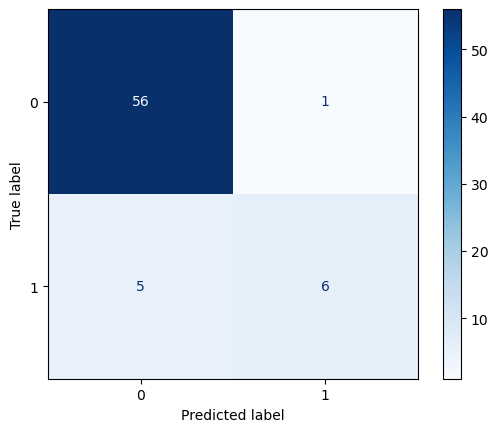

In [15]:
######################################################################
# SIMPLE SVM PIPELINE
######################################################################

thresh = 0.3

# Undersampling
X_all = df_clean[feature_cols].values
y_all = df_clean[target_col].values

rus = RandomUnderSampler(sampling_strategy=0.2, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X_all, y_all)
print(f"After resampling: {(y_resampled==0).sum()} non-fraud / {(y_resampled==1).sum()} fraud")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, stratify = y_resampled, random_state = random_state)

# Building pipeline
pipeline = Pipeline([('scaler', StandardScaler()),('svm',    SVC(probability=True, max_iter=2000, random_state=random_state))])

# Grid search
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid_pipeline,
    scoring    = 'average_precision',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train)
print(f"\nBest params : {grid_search.best_params_}")
print(f"Best PR-AUC : {grid_search.best_score_:.4f}")

#  Evaluation of the model on test data
best_pipeline = grid_search.best_estimator_
y_proba       = best_pipeline.predict_proba(X_test)[:, 1]


y_pred  = (y_proba >= thresh).astype(int)

metrics = evaluate_predictions(y_test, y_pred, y_proba)

print(f"\nTEST SET METRICS")
print('-' * 10)
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")
print(f"  PR-AUC    : {metrics['pr_auc']:.4f}")
print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")

cm = confusion_matrix(y_test, y_pred)


view = ConfusionMatrixDisplay(confusion_matrix=cm)
view.plot(cmap=plt.cm.Blues)
plt.show()

The performance is much better when using a simpler approach with poly kernel performing the best.

The above parameters could be used in othe FDUS undersampling method as well.

After resampling: 280 non-fraud / 56 fraud
Fitting 5 folds for each of 12480 candidates, totalling 62400 fits

Best params : {'svm__C': 50, 'svm__class_weight': 'balanced', 'svm__coef0': 2.0, 'svm__degree': 3, 'svm__gamma': 0.001, 'svm__kernel': 'poly'}
Best PR-AUC : 0.6534

FULL DATASET METRICS
----------
  Precision : 0.0023
  Recall    : 0.2321
  F1 Score  : 0.0046
  PR-AUC    : 0.0033
  ROC-AUC   : 0.9086


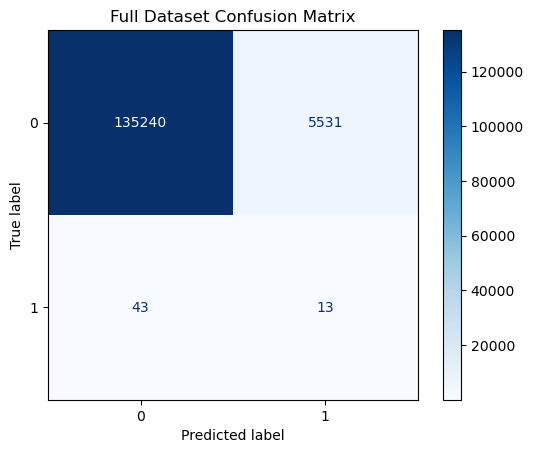

In [16]:
######################################################################
# SIMPLE SVM PIPELINE WITH TEST AGAINST ALL AVAILABLE DATA
######################################################################
thresh = 0.5

# Undersampling
X_all = df_clean[feature_cols].values
y_all = df_clean[target_col].values

rus = RandomUnderSampler(sampling_strategy=0.2, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X_all, y_all)
print(f"After resampling: {(y_resampled==0).sum()} non-fraud / {(y_resampled==1).sum()} fraud")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=random_state)

# Building pipeline
pipeline = Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, max_iter=2000, random_state=random_state))])

# Grid search
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid_pipeline,
    scoring    = 'average_precision',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train)
print(f"\nBest params : {grid_search.best_params_}")
print(f"Best PR-AUC : {grid_search.best_score_:.4f}")

# ── Evaluate on full original dataset ────────────────────────────────
best_pipeline  = grid_search.best_estimator_
y_proba_full   = best_pipeline.predict_proba(X_all)[:, 1]
y_pred_full    = (y_proba_full >= thresh).astype(int)

metrics = evaluate_predictions(y_all, y_pred_full, y_proba_full)

print(f"\nFULL DATASET METRICS")
print('-' * 10)
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")
print(f"  PR-AUC    : {metrics['pr_auc']:.4f}")
print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")

cm = confusion_matrix(y_all, y_pred_full)
view = ConfusionMatrixDisplay(confusion_matrix=cm)
view.plot(cmap=plt.cm.Blues)
plt.title('Full Dataset Confusion Matrix')
plt.show()

## Attempt 4

Updating the parameters using tuning

In [17]:
param_grid = [
    {   # Linear: fast, good for high-dimensional data
        'kernel'       : ['linear'],
        'C'            : [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500],
        'class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:15}, {0:1, 1:20}, {0:1, 1:30}, {0:1, 1:50}, {0:1, 1:75}, {0:1, 1:100}]
    },
    {   # RBF: handles non-linear boundaries, most commonly best performer
        'kernel'       : ['rbf'],
        'C'            : [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000],
        'gamma'        : ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001],
        'class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:15}, {0:1, 1:20}, {0:1, 1:30}, {0:1, 1:50}, {0:1, 1:75}, {0:1, 1:100}]
    },
    {   # Sigmoid: neural-network-like boundary
        'kernel'       : ['sigmoid'],
        'C'            : [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500],
        'gamma'        : ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001, 0.00001],
        'coef0'        : [0.0, 0.1, 0.5, 1.0, 2.0, 5.0],
        'class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:20}, {0:1, 1:50}, {0:1, 1:75}, {0:1, 1:100}]
        
    },
    {   # Poly
        'kernel'       : ['poly'],
        'C'            : [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500],
        'gamma'        : ['scale', 'auto', 0.1, 0.01, 0.001],
        'degree'       : [2, 3, 4, 5],
        'coef0'        : [0.0, 0.1, 0.5, 1.0, 2.0],
        'class_weight' : ['balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:20}, {0:1, 1:50}, {0:1, 1:100}]
    }
]

In [18]:
# Since FDUS (SVM varient) performed better, we will be using that varient for attempt 4 as well 

In [19]:
######################################################################
# STRATIFIED GROUP K-FOLD CV WITH FDUS + SVM GRID SEARCH
######################################################################

# Outer CV groups by NPI — same provider never leaks across train/test
outer_cv = StratifiedGroupKFold(n_splits=n_cv_folds, shuffle=True, random_state=random_state)

# Result storage
fold_metrics     = []
fold_best_params = []
fold_models      = []
all_test_indices = []
all_test_probas  = []
all_test_labels  = []

start_time = time()

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1} of {n_cv_folds}")
    print(f"{'='*60}")

    # Slice train / test for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"  Train : {len(X_train):,} rows  |  fraud={y_train.sum()}  non-fraud={(y_train==0).sum():,}")
    print(f"  Test  : {len(X_test):,} rows   |  fraud={y_test.sum()}  non-fraud={(y_test==0).sum():,}")

    # Skip if no fraud in test — nothing meaningful to evaluate
    if y_test.sum() == 0:
        print("  SKIPPED — no fraud cases in test fold")
        continue

    # ── Step 1: Scale features ───────────────────────────────────────
    # Always fit scaler on training data only to avoid data leakage
    t = time()
    scaler        = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print(f"  [1/4] Scaling          ... done ({time()-t:.1f}s)")

    # ── Step 2: FDUS undersampling ───────────────────────────────────
    # Undersample majority class (non-fraud) using boundary-aware sampling
    t            = time()
    majority_idx = np.where(y_train == 0)[0]
    minority_idx = np.where(y_train == 1)[0]

    fdus = FDUSUndersampler(
        n_clusters   = fdus_n_clusters,
        alpha        = fdus_alpha,
        target_ratio = fdus_ratio,
        random_state = random_state
    )
    X_train_resampled, y_train_resampled = fdus.fit_resample(
        X_train_scaled[majority_idx],
        X_train_scaled[minority_idx]
    )
    print(f"  [2/4] FDUS resampling  ... done ({time()-t:.1f}s)")

    # ── Step 3: Grid search for best SVM hyperparameters ────────────
    # Inner CV runs only on the resampled training data
    t        = time()
    inner_cv = StratifiedKFold(
        n_splits     = min(3, int(y_train_resampled.sum())),
        shuffle      = True,
        random_state = random_state
    )

    grid_search = GridSearchCV(
        estimator  = SVC(probability=True, max_iter=2000, random_state=random_state),
        param_grid = param_grid,
        scoring    = primary_metric,
        cv         = inner_cv,
        n_jobs     = -1,
        verbose    = 0
    )
    grid_search.fit(X_train_resampled, y_train_resampled)
    print(f"  [3/4] Grid search      ... done ({time()-t:.1f}s)")

    best_svm = grid_search.best_estimator_
    fold_best_params.append(grid_search.best_params_)
    fold_models.append((scaler, best_svm))

    print(f"  Best inner CV PR-AUC : {grid_search.best_score_:.4f}")
    print(f"  Best params          : {grid_search.best_params_}")

    # ── Step 4: Evaluate on held-out test fold ───────────────────────
    # Test fold is the original imbalanced data — real-world conditions
    t            = time()
    y_test_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

    all_test_indices.extend(test_idx.tolist())
    all_test_probas.extend(y_test_proba.tolist())
    all_test_labels.extend(y_test.tolist())

    fold_auc_roc = roc_auc_score(y_test, y_test_proba)
    fold_auc_pr  = average_precision_score(y_test, y_test_proba)

    fold_metrics.append({
        'fold'            : fold_idx + 1,
        'auc_roc'         : fold_auc_roc,
        'auc_pr'          : fold_auc_pr,
        'train_fraud'     : int(y_train.sum()),
        'test_fraud'      : int(y_test.sum()),
        'train_resampled' : len(y_train_resampled)
    })

    print(f"  [4/4] Evaluation       ... done ({time()-t:.1f}s)")
    print(f"  Fold AUC-ROC : {fold_auc_roc:.4f}")
    print(f"  Fold AUC-PR  : {fold_auc_pr:.4f}")

######################################################################
# SUMMARY
######################################################################

elapsed       = time() - start_time
cv_results_df = pd.DataFrame(fold_metrics)

print(f"\nCROSS-VALIDATION SUMMARY  ({elapsed:.1f}s total)")
print('-' * 60)
print(cv_results_df.to_string(index=False))
print(f"\nMean AUC-PR  : {cv_results_df['auc_pr'].mean():.4f}  (+/- {cv_results_df['auc_pr'].std():.4f})")
print(f"Mean AUC-ROC : {cv_results_df['auc_roc'].mean():.4f}  (+/- {cv_results_df['auc_roc'].std():.4f})")


FOLD 1 of 5
  Train : 112,633 rows  |  fraud=37  non-fraud=112,596
  Test  : 28,194 rows   |  fraud=19  non-fraud=28,175
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 185)... done
    FDUS: 217 samples (180 maj / 37 min)
  [2/4] FDUS resampling  ... done (2.6s)
  [3/4] Grid search      ... done (31.6s)
  Best inner CV PR-AUC : 0.5638
  Best params          : {'C': 10, 'class_weight': {0: 1, 1: 5}, 'gamma': 0.01, 'kernel': 'rbf'}
  [4/4] Evaluation       ... done (0.2s)
  Fold AUC-ROC : 0.6248
  Fold AUC-PR  : 0.0017

FOLD 2 of 5
  Train : 112,672 rows  |  fraud=41  non-fraud=112,631
  Test  : 28,155 rows   |  fraud=15  non-fraud=28,140
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 205)... done
    FDUS: 221 samples (180 maj / 41 min)
  [2/4] FDUS resampling  ... done (3.3s)
  [3/4] Grid search      ... done (32.5s)
  Best inner CV PR

The results from this attempt has the been the worst yet.

Maybe One-Class SVM would yield better results.